# 3.1 — Основные метрики и калибровка

**Папка 3 «Оценка», подноутбук 1.** Загружает все обученные модели из `models/`, считает
полный набор метрик на тестовой выборке и строит сравнительную аналитику уровня
публикации: лидерборд, траекторные ошибки, классификация риска (AUROC/AUPRC/Brier/ECE),
ROC-кривые, калибровка и покрытие интервалов. Все рисунки и таблицы — на английском.

## Окружение, данные и модели

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset
from liquefaction_ai.training import load_model_metadata, load_weights_into
from liquefaction_ai.models import (DPIFlow, EVTNeuralSSM, GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline, TransformerBaseline, FTTransformer,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow, DPIEvtNet)
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, english_metric_table
from liquefaction_ai.models import CatBoostBaseline

CLASS_REGISTRY = {"RiskMLP": RiskMLP, "GRUBaseline": GRUBaseline, "TCNBaseline": TCNBaseline, "LSTMBaseline": LSTMBaseline, "TransformerBaseline": TransformerBaseline, "FTTransformer": FTTransformer, "PINNBaseline": PINNBaseline, "DeepStateBaseline": DeepStateBaseline, "RealNVPFlow": RealNVPFlow, "NeuralSplineFlow": NeuralSplineFlow,
                  "DPIFlow": DPIFlow, "EVTNeuralSSM": EVTNeuralSSM, "DPIEvtNet": DPIEvtNet}
MODEL_NAMES = ["mlp_risk", "gru", "tcn", "lstm", "transformer", "ft_transformer", "pinn", "deepstate", "realnvp", "nsf", "dpi_flow", "evt_ssm", "dpi_evt"]

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
test = benchmark["test"]


def load_trained(name):
    """Восстановить модель по сохранённым гиперпараметрам и весам."""
    hp, hist = load_model_metadata(MODELS_DIR, name)
    model = CLASS_REGISTRY[hp["model_type"]](**hp["model_kwargs"])
    load_weights_into(model, MODELS_DIR, name, device)
    return model, hp, hist
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from liquefaction_ai.viz import bar, calibration_plot, grouped_bar, lines

models, predictions, sample_tables, rows = {}, {}, {}, []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name)
    disp = hp["display_name"]
    out = collect_outputs(model, test, config, device)
    met, sample_df = compute_metrics(disp, out, test, config)
    models[disp] = model; predictions[disp] = out; sample_tables[disp] = sample_df; rows.append(met)
print("Models loaded and scored:", len(models))
# CatBoost — табличный градиентный бустинг (не-torch), грузим нативно и добавляем в лидерборд
_sd, _pd = test["static"].shape[1], test["prefix_summary"].shape[1]
_cb = CatBoostBaseline(_sd, _pd).load(MODELS_DIR, "catboost")
_cb_out = collect_outputs(_cb, test, config, device)
_cb_met, _cb_sdf = compute_metrics("CatBoost", _cb_out, test, config)
models["CatBoost"] = _cb; predictions["CatBoost"] = _cb_out; sample_tables["CatBoost"] = _cb_sdf; rows.append(_cb_met)
print("CatBoost added | total models:", len(models))

Models loaded and scored: 13
CatBoost added | total models: 14


## Leaderboard

In [2]:
leaderboard = pd.DataFrame(rows).sort_values(["Traj_RMSE", "Brier"], na_position="last").reset_index(drop=True)
display(english_metric_table(leaderboard).round(4))
leaderboard.to_csv(REPO_ROOT / "results" / "tables" / "full_leaderboard.csv", index=False)
print("saved results/tables/full_leaderboard.csv")

# === Раздельные лидерборды (честность сравнения) ===
# Risk-only модели (CatBoost, FT-Transformer, MLP-Risk) не выдают траекторию/CRR — их сведение
# в один лидерборд с физическими моделями вводит в заблуждение. Делим на два:
#   • leaderboard_risk.csv        — все модели, только метрики риска/события;
#   • leaderboard_trajectory.csv  — только state-space/physics модели (есть траектория PPR).
leaderboard["Produces_Trajectory"] = leaderboard["Traj_RMSE"].notna().astype(int)
_tab = REPO_ROOT / "results" / "tables"
_risk_cols = ["model", "AUROC", "AUPRC", "Brier", "ECE",
              "N_liq_logMAE", "N_liq_MAE", "N_liq_n_observed", "Produces_Trajectory"]
risk_lb = (leaderboard[[c for c in _risk_cols if c in leaderboard.columns]]
           .sort_values("AUROC", ascending=False).reset_index(drop=True))
risk_lb.to_csv(_tab / "leaderboard_risk.csv", index=False)
_traj_cols = ["model", "Traj_RMSE", "Traj_CRPS", "Calibration_Error", "Coverage_90",
              "Physics_Violation_Rate", "CRR_RMSE", "N_CRR_test", "N_CRR_objects",
              "N_liq_logMAE", "N_liq_n_observed"]
traj_lb = (leaderboard[leaderboard["Produces_Trajectory"] == 1][[c for c in _traj_cols if c in leaderboard.columns]]
           .sort_values("Traj_RMSE").reset_index(drop=True))
traj_lb.to_csv(_tab / "leaderboard_trajectory.csv", index=False)
print(f"saved leaderboard_risk.csv ({len(risk_lb)} моделей) и leaderboard_trajectory.csv ({len(traj_lb)} моделей)")
print(f"CRR-метрика опирается на N_CRR_test={int(leaderboard['N_CRR_test'].dropna().max() or 0)} образцов "
      f"из N_CRR_objects={int(leaderboard['N_CRR_objects'].dropna().max() or 0)} объектов — малая выборка.")

,Model,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,...,Trajectory RMSE (liquefied),"Trajectory RMSE (no-liq, stabilized)","Trajectory RMSE (no-liq, not stabilized)",Trajectory RMSE (balanced over states),Trajectory RMSE (worst state),Post-prefix RMSE (liquefied),"Post-prefix RMSE (no-liq, stabilized)","Post-prefix RMSE (no-liq, not stabilized)",Post-prefix RMSE (balanced over states),Post-prefix RMSE (worst state)
0,Transformer,176.0045,264.6094,0.3085,0.5414,229,True,0.5632,141.0611,0.2685,...,0.0453,0.1119,0.0747,0.0773,0.1119,0.0516,0.1222,0.1101,0.0947,0.1222
1,RealNVP,294.4112,534.5439,0.4327,0.7050,229,True,0.7570,282.7912,0.1481,...,0.0507,0.1263,0.1213,0.0994,0.1263,0.0568,0.1382,0.0889,0.0946,0.1382
2,DPI-EVT,289.9166,539.1598,0.8386,1.2783,229,True,1.7266,535.6761,0.0000,...,0.0859,0.1019,0.3643,0.1841,0.3643,0.0877,0.1102,0.2304,0.1428,0.2304
3,GRU,256.8568,395.0186,0.5219,0.7735,229,True,0.9070,122.2357,0.7130,...,0.0745,0.1351,0.0879,0.0992,0.1351,0.0851,0.1474,0.1164,0.1163,0.1474
4,TCN,151.9429,236.4110,0.3109,0.5012,229,True,0.5674,99.3930,0.3796,...,0.0695,0.1432,0.0771,0.0966,0.1432,0.0796,0.1566,0.0950,0.1104,0.1566
5,DeepState,282.2357,422.9575,0.4586,0.7041,229,True,0.8351,232.5175,0.0093,...,0.1019,0.1332,0.0909,0.1087,0.1332,0.1065,0.1433,0.0838,0.1112,0.1433
6,EVT-NeuralSSM,310.7260,548.8357,0.8362,1.2602,229,True,1.7061,526.8932,0.0000,...,0.0779,0.1371,0.3086,0.1745,0.3086,0.0778,0.1477,0.1748,0.1334,0.1748
7,DPI-Flow,218.4413,695.4034,0.3535,0.7587,229,True,0.7220,438.3045,0.3889,...,0.0921,0.1369,0.3384,0.1891,0.3384,0.0899,0.1490,0.1441,0.1277,0.1490
8,LSTM,294.7459,498.3906,0.3662,0.6123,229,True,0.4742,56.3825,0.5926,...,0.0679,0.1573,0.0979,0.1077,0.1573,0.0646,0.1694,0.1220,0.1186,0.1694
9,PINN,715.7772,787.0878,1.0387,1.3511,229,True,1.8790,689.7820,0.0000,...,0.0992,0.1556,0.1409,0.1319,0.1556,0.1089,0.1668,0.1100,0.1285,0.1668


saved results/tables/full_leaderboard.csv
saved leaderboard_risk.csv (14 моделей) и leaderboard_trajectory.csv (11 моделей)
CRR-метрика опирается на N_CRR_test=85 образцов из N_CRR_objects=1 объектов — малая выборка.


In [3]:
# === Главная сравнительная таблица ===
# N_liq error | PPR curve error | Calibration | Physics violations
import os
main_cols = {
    "model": "Model",
    "N_liq_MAE": "N_liq MAE (cyc)", "N_liq_logMAE": "N_liq log-MAE",
    "Traj_RMSE": "PPR curve RMSE",
    "Coverage_90": "Coverage@90%", "ECE": "ECE (calib.)",
    "Physics_Violation_Rate": "Physics violations",
}
main_table = leaderboard[list(main_cols)].rename(columns=main_cols)
display(main_table.round(4))
os.makedirs(REPO_ROOT / "results" / "tables", exist_ok=True)
main_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "main_comparison.csv", index=False)
print("saved results/tables/main_comparison.csv")

,Model,N_liq MAE (cyc),N_liq log-MAE,PPR curve RMSE,Coverage@90%,ECE (calib.),Physics violations
0,Transformer,176.0045,0.3085,0.0926,0.6894,0.0041,0.0306
1,RealNVP,294.4112,0.4327,0.1049,0.6138,0.0361,0.2445
2,DPI-EVT,289.9166,0.8386,0.1052,0.9032,0.0270,0.0000
3,GRU,256.8568,0.5219,0.1159,0.6609,0.0204,0.9258
4,TCN,151.9429,0.3109,0.1205,0.6718,0.0275,0.9170
5,DeepState,282.2357,0.4586,0.1221,0.7309,0.0257,0.0000
6,EVT-NeuralSSM,310.7260,0.8362,0.1234,0.8731,0.0932,0.0000
7,DPI-Flow,218.4413,0.3535,0.1279,0.7556,0.0599,0.0087
8,LSTM,294.7459,0.3662,0.1308,0.6208,0.0285,1.0000
9,PINN,715.7772,1.0387,0.1373,0.7359,0.1122,0.0437


saved results/tables/main_comparison.csv


## Probabilistic & physics quality — structured models

Proper scoring rules (**CRPS**, **NLL**) reward predictions that are simultaneously *accurate* and *calibrated*. DPI-Flow, EVT-NeuralSSM and DPI-EVT emit a physical CRR(N) resistance curve. The current grouped leaderboard below is the source of truth for which model leads each metric; this section highlights that the structured models combine calibrated uncertainty, zero monotonicity violations and CRR capability, while black-box flows/RNNs routinely violate monotonicity.


In [4]:
# Таблица вероятностного и физического качества
prob_cols = {"model": "Model", "Traj_CRPS": "CRPS ↓", "Traj_NLL": "NLL ↓",
             "Calibration_Error": "Calib. err ↓", "Coverage_90": "Cov@90%",
             "Physics_Violation_Rate": "Physics viol. ↓", "CRR_RMSE": "CRR RMSE ↓"}
prob_table = leaderboard[list(prob_cols)].rename(columns=prob_cols)
display(prob_table.round(4))
prob_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "probabilistic_quality.csv", index=False)
print("saved results/tables/probabilistic_quality.csv")

,Model,CRPS ↓,NLL ↓,Calib. err ↓,Cov@90%,Physics viol. ↓,CRR RMSE ↓
0,Transformer,0.0581,-0.6570,0.2036,0.6894,0.0306,NaN
1,RealNVP,0.0636,0.9793,0.2797,0.6138,0.2445,NaN
2,DPI-EVT,0.0546,-0.9303,0.0097,0.9032,0.0000,0.1903
3,GRU,0.0739,-0.0346,0.2322,0.6609,0.9258,NaN
4,TCN,0.0747,-0.1282,0.2213,0.6718,0.9170,NaN
5,DeepState,0.0750,-0.3314,0.1630,0.7309,0.0000,NaN
6,EVT-NeuralSSM,0.0709,-0.6743,0.0219,0.8731,0.0000,0.2292
7,DPI-Flow,0.0765,-0.5479,0.1379,0.7556,0.0087,0.2419
8,LSTM,0.0828,0.2022,0.2718,0.6208,1.0000,NaN
9,PINN,0.0866,-0.4021,0.1492,0.7359,0.0437,NaN


saved results/tables/probabilistic_quality.csv


In [5]:
# Матрица возможностей: что вообще умеет каждая модель
PHYS_MODELS = {"DPI-Flow", "EVT-NeuralSSM", "DPI-EVT"}
lb_idx = leaderboard.set_index("model")
cap = []
for disp, out in predictions.items():
    viol = float(lb_idx.loc[disp, "Physics_Violation_Rate"]) if disp in lb_idx.index else float("nan")
    cap.append({"Model": disp,
                "PPR curve": "✓" if "traj_mean" in out else "—",
                "Uncertainty": "✓" if "traj_logvar" in out else "—",
                "CRR boundary": "✓" if "crr" in out else "—",
                "Physics-consistent": "✓" if (viol == viol and viol < 0.05) else "—"})
capability = pd.DataFrame(cap).set_index("Model")
display(capability)

,PPR curve,Uncertainty,CRR boundary,Physics-consistent
Model,,,,
MLP-Risk,—,—,—,—
GRU,✓,✓,—,—
TCN,✓,✓,—,—
LSTM,✓,✓,—,—
Transformer,✓,✓,—,✓
FT-Transformer,—,—,—,—
PINN,✓,✓,—,✓
DeepState,✓,✓,—,✓
RealNVP,✓,✓,—,—


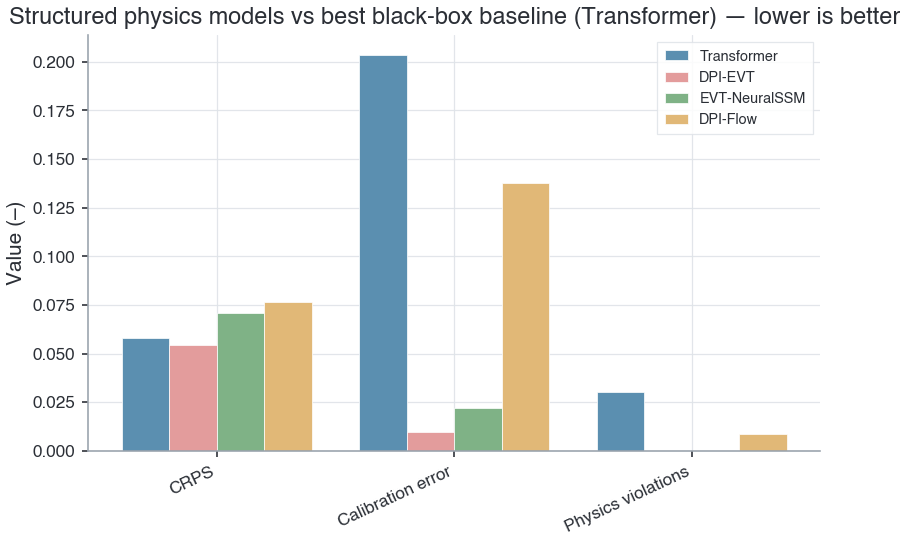

DPI-EVT: CRPS +6.0% vs Transformer | calib.err 0.010 | physics-viol 0.000 | CRR RMSE 0.1903 (baselines: n/a)
DPI-Flow: CRPS -31.7% vs Transformer | calib.err 0.138 | physics-viol 0.009 | CRR RMSE 0.2419 (baselines: n/a)
EVT-NeuralSSM: CRPS -22.1% vs Transformer | calib.err 0.022 | physics-viol 0.000 | CRR RMSE 0.2292 (baselines: n/a)


In [6]:
# Наглядное сравнение структурных моделей с лучшим ЧЁРНЫМ ЯЩИКОМ
PHYS_INFORMED = {"DPI-Flow", "EVT-NeuralSSM", "DPI-EVT", "PINN"}   # физически-информированные — не baseline
blackbox = leaderboard[~leaderboard["model"].isin(PHYS_INFORMED)].dropna(subset=["Traj_CRPS"])
best_base = blackbox.sort_values("Traj_CRPS").iloc[0]["model"]
sel = leaderboard[leaderboard["model"].isin(list(PHYS_MODELS) + [best_base])].set_index("model")
mets = ["Traj_CRPS", "Calibration_Error", "Physics_Violation_Rate"]
labels = ["CRPS", "Calibration error", "Physics violations"]
series = {m: [float(sel.loc[m, k]) for k in mets] for m in sel.index}
grouped_bar(labels, series,
            title=f"Structured physics models vs best black-box baseline ({best_base}) — lower is better",
            ylabel="Value (–)", save=SAVE_FIGS, fig_id="3_1_structured_advantage").show()
for m in PHYS_MODELS:
    if m in sel.index:
        d = (sel.loc[best_base, "Traj_CRPS"] - sel.loc[m, "Traj_CRPS"]) / sel.loc[best_base, "Traj_CRPS"] * 100
        print(f"{m}: CRPS {d:+.1f}% vs {best_base} | calib.err {sel.loc[m,'Calibration_Error']:.3f} | "
              f"physics-viol {sel.loc[m,'Physics_Violation_Rate']:.3f} | CRR RMSE {sel.loc[m,'CRR_RMSE']:.4f} (baselines: n/a)")

## P³-Score и Pareto-ранжирование (публикационное)

Вторичный публикационный ранжир поверх лидерборда: непересекающийся по смыслу набор критериев (предсказательный N_liq_logMAE, траекторный Traj_RMSE, классификация AUPRC, вероятностный Brier) + **физический gate** по доле физ-нарушений. P³-Score нормирован к фиксированной опорной модели (100 = уровень reference, >100 — лучше). Pareto-фронт — недоминируемая сортировка по тем же критериям.

In [7]:
from liquefaction_ai.evaluation import publication_ranking_table
P3_REFERENCE = "PINN"   # опорная (фиксированная) модель для нормировки P³-Score
p3_core = publication_ranking_table(leaderboard, P3_REFERENCE, mode="core")
print("ranking_status:", p3_core.attrs.get("ranking_status", "ok"))
display(english_metric_table(p3_core).round(3))
p3_core.round(4).to_csv(REPO_ROOT / "results" / "tables" / "p3_core_ranking.csv", index=False)
print("saved results/tables/p3_core_ranking.csv")

ranking_status: ok


,Model,Pareto front (raw),Pareto front (adm.),P³ Core raw,P³ Core admissible,Physically unreliable,Competence gate failed,Competence gate reason,Excluded (adm.),Physical penalty,...,Trajectory RMSE,Brier,AUPRC,MAE N_liq (cycles),RMSE N_liq (cycles),AUROC,ECE,Trajectory MAE,Trajectory MSE,Produces CRR
0,DeepState,1.0,1.0,176.553,176.553,False,False,,False,0.000,...,0.122,0.017,0.999,282.236,422.957,0.999,0.026,0.092,0.015,False
1,DPI-Flow,1.0,1.0,160.832,160.832,False,False,,False,0.000,...,0.128,0.038,0.995,218.441,695.403,0.995,0.060,0.097,0.016,True
2,Transformer,1.0,1.0,676.157,144.582,False,False,,False,1.543,...,0.093,0.000,1.000,176.004,264.609,1.000,0.004,0.065,0.009,False
3,DPI-EVT,2.0,2.0,117.948,117.948,False,False,,False,0.000,...,0.105,0.022,0.992,289.917,539.160,0.993,0.027,0.073,0.011,True
4,EVT-NeuralSSM,2.0,2.0,96.970,96.970,False,False,,False,0.000,...,0.123,0.065,0.993,310.726,548.836,0.994,0.093,0.092,0.015,True
5,PINN,2.0,NaN,100.000,0.000,False,True,N_liq_logMAE=1.039>3×best(0.309),True,2.525,...,0.137,0.036,0.998,715.777,787.088,0.998,0.112,0.109,0.019,False
6,RealNVP,1.0,NaN,179.371,0.000,True,False,,True,17.591,...,0.105,0.022,0.997,294.411,534.544,0.997,0.036,0.069,0.011,False
7,Neural Spline Flow,2.0,NaN,148.909,0.000,True,False,,True,55.582,...,0.167,0.018,0.997,373.821,619.105,0.997,0.029,0.108,0.028,False
8,TCN,2.0,NaN,243.354,0.000,True,False,,True,68.027,...,0.121,0.008,1.000,151.943,236.411,1.000,0.027,0.082,0.015,False
9,GRU,3.0,NaN,167.270,0.000,True,False,,True,68.682,...,0.116,0.015,1.000,256.857,395.019,1.000,0.020,0.080,0.013,False


saved results/tables/p3_core_ranking.csv


## Trajectory error and risk classification

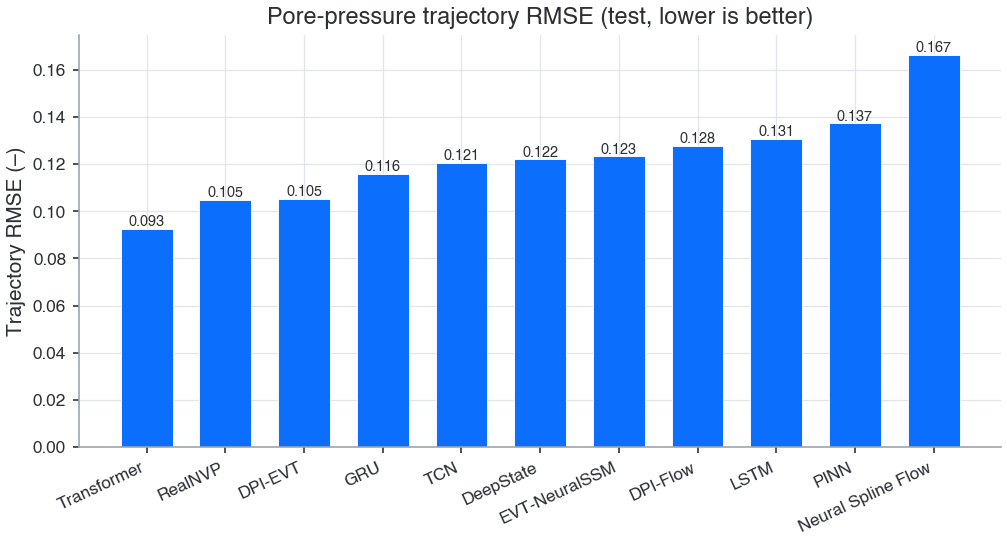

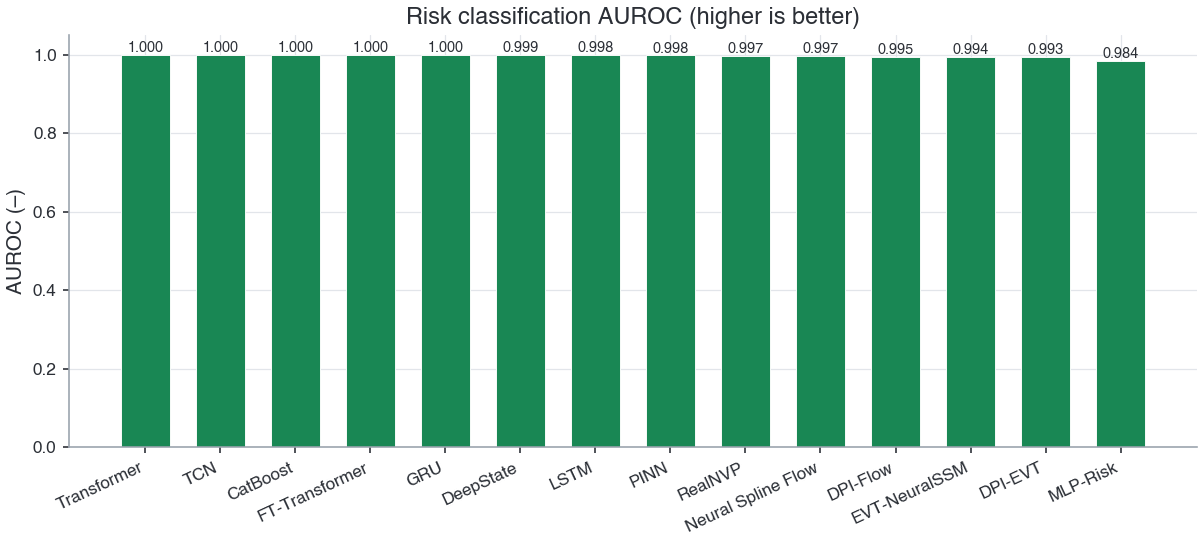

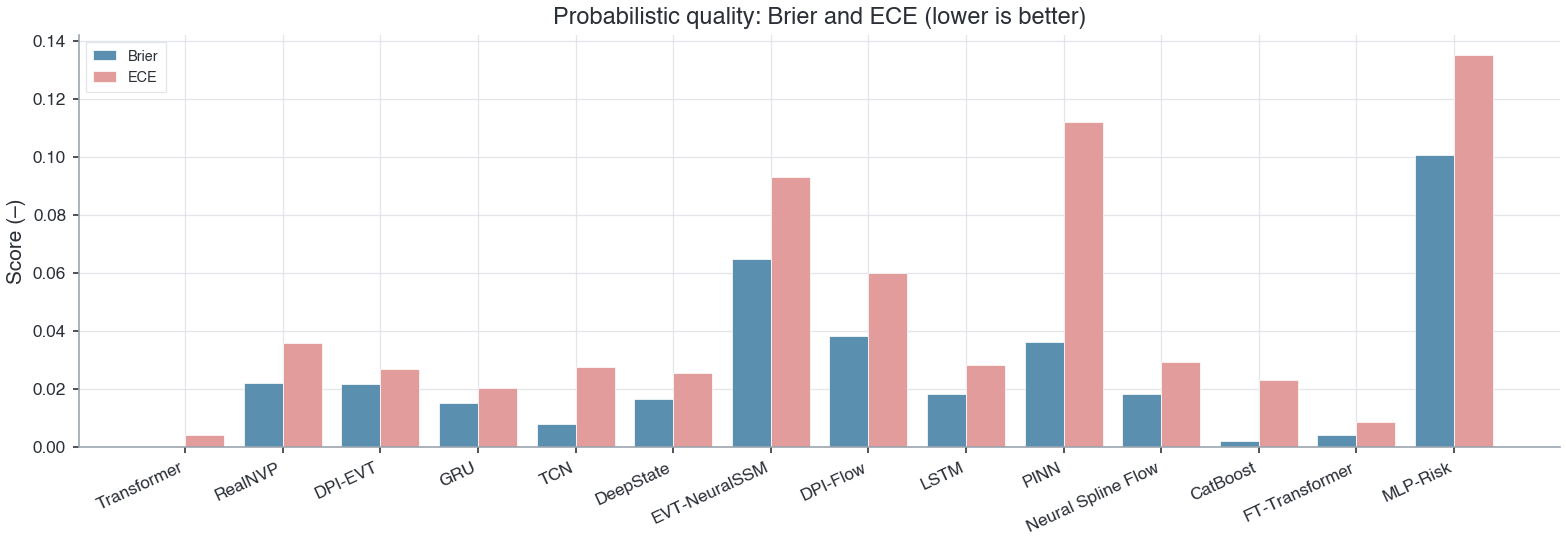

In [8]:
traj_df = leaderboard.dropna(subset=["Traj_RMSE"]).sort_values("Traj_RMSE")
bar(traj_df["model"], traj_df["Traj_RMSE"], title="Pore-pressure trajectory RMSE (test, lower is better)",
    ylabel="Trajectory RMSE (–)", color="#0b6efd", save=SAVE_FIGS, fig_id="3_1_leaderboard_rmse").show()
auc_df = leaderboard.sort_values("AUROC", ascending=False)
bar(auc_df["model"], auc_df["AUROC"], title="Risk classification AUROC (higher is better)",
    ylabel="AUROC (–)", color="#198754", save=SAVE_FIGS, fig_id="3_1_auroc").show()
grouped_bar(leaderboard["model"].tolist(),
            {"Brier": leaderboard["Brier"].tolist(), "ECE": leaderboard["ECE"].tolist()},
            title="Probabilistic quality: Brier and ECE (lower is better)", ylabel="Score (–)",
            save=SAVE_FIGS, fig_id="3_1_brier_ece").show()

## ROC curves

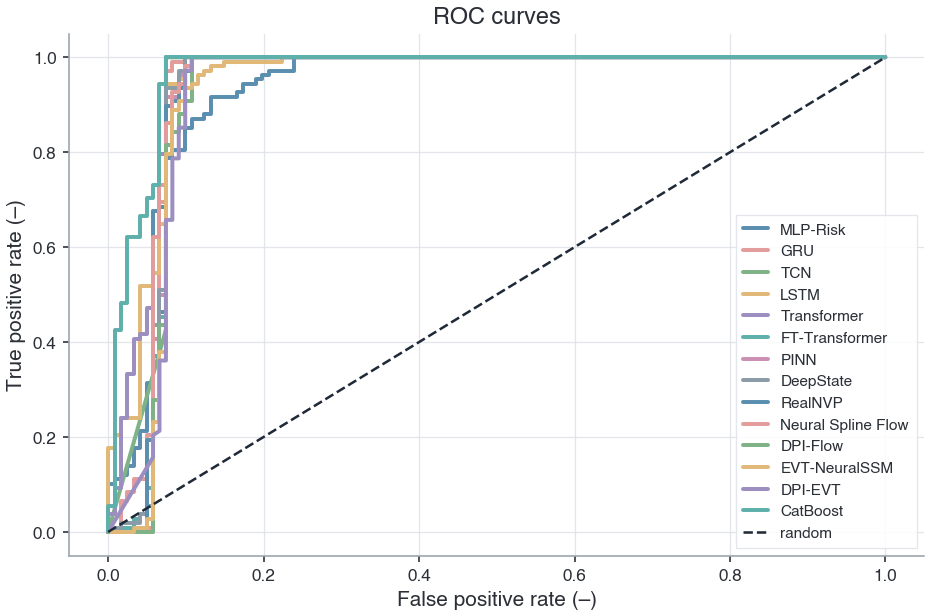

In [9]:
y_true = test["label"].cpu().numpy()
series = []
for disp, out in predictions.items():
    fpr, tpr, _ = roc_curve(y_true, out["risk_prob"])
    series.append({"x": fpr, "y": tpr, "name": disp})
series.append({"x": [0, 1], "y": [0, 1], "name": "random", "color": "#1f2937", "dash": "dash", "width": 1.4})
lines(series, title="ROC curves", xlabel="False positive rate (–)", ylabel="True positive rate (–)",
      save=SAVE_FIGS, fig_id="3_1_roc_curves").show()

## Risk calibration

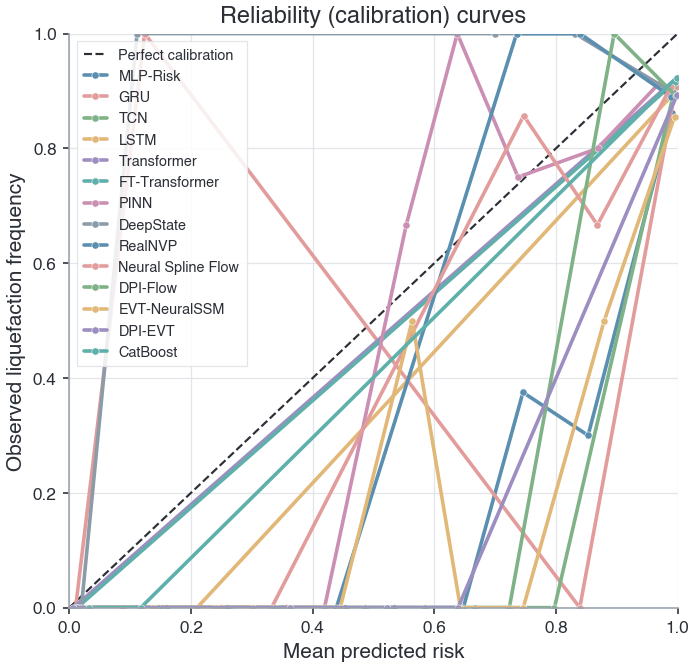

In [10]:
curves = {}
for disp in sample_tables:
    st = sample_tables[disp]
    if st["liq_label"].nunique() > 1:
        frac_pos, mean_pred = calibration_curve(st["liq_label"], st["risk_prob_pred"], n_bins=10)
        curves[disp] = (mean_pred, frac_pos)
calibration_plot(curves, title="Reliability (calibration) curves",
                 save=SAVE_FIGS, fig_id="3_1_calibration").show()

## Post-hoc temperature scaling

A single temperature T is fitted on the validation set per model and applied to the test
risk logits. This is a fair, universal post-hoc calibration step — it improves Brier/ECE
without changing AUROC (ranking is preserved).

,Model,T,Brier raw,Brier cal,ECE raw,ECE cal
0,MLP-Risk,0.94,0.1358,0.1370,0.1693,0.1693
1,GRU,1.80,0.0537,0.0518,0.0589,0.0735
2,TCN,1.51,0.0470,0.0502,0.0651,0.0873
3,LSTM,1.30,0.0563,0.0562,0.0663,0.0733
4,Transformer,1.40,0.0393,0.0394,0.0422,0.0486
5,FT-Transformer,1.22,0.0431,0.0427,0.0476,0.0507
6,PINN,0.36,0.0732,0.0570,0.1190,0.0762
7,DeepState,2.21,0.0550,0.0598,0.0639,0.0780
8,RealNVP,1.60,0.0604,0.0624,0.0739,0.0745
9,Neural Spline Flow,1.12,0.0568,0.0574,0.0658,0.0673


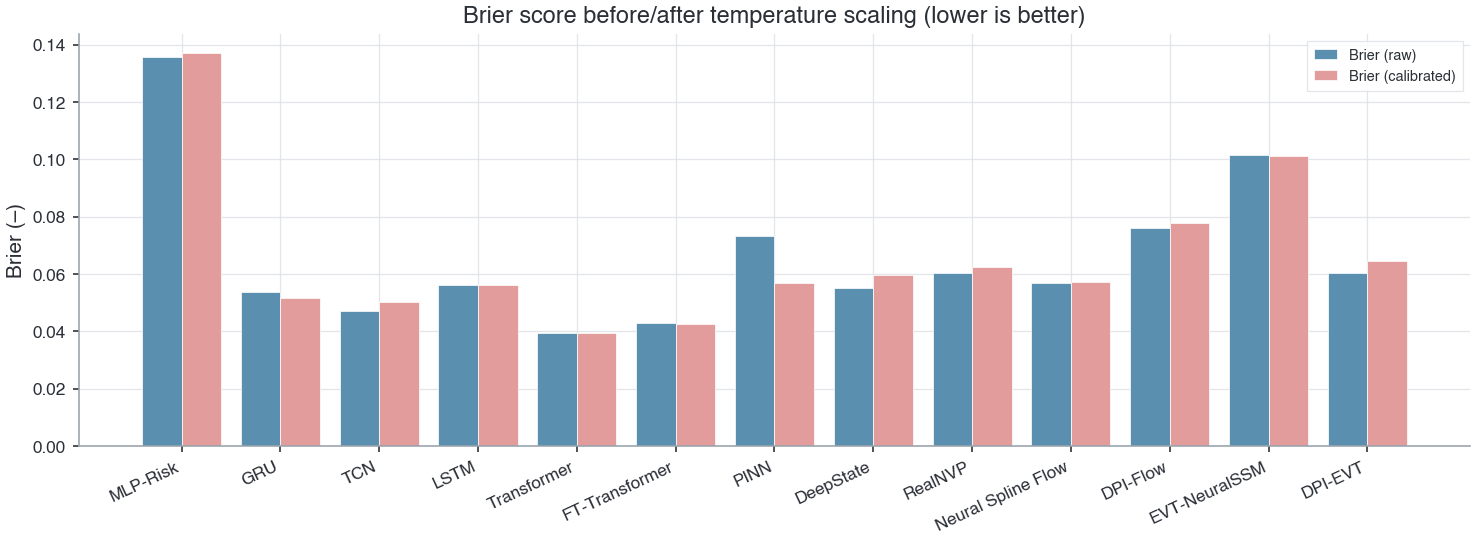

In [11]:
from liquefaction_ai.evaluation import fit_temperature, apply_temperature, expected_calibration_error, safe_binary_metrics

val = benchmark["val"]; y_val = val["label"].cpu().numpy(); y_test = test["label"].cpu().numpy()
cal_rows = []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name); disp = hp["display_name"]
    val_out = collect_outputs(model, val, config, device)
    vp = np.clip(val_out["risk_prob"], 1e-6, 1 - 1e-6); v_logit = np.log(vp / (1 - vp))
    T = fit_temperature(v_logit, y_val); T = float(np.clip(T if np.isfinite(T) else 1.0, 0.05, 20.0))
    p_raw = np.clip(np.nan_to_num(predictions[disp]["risk_prob"], nan=0.5), 1e-6, 1 - 1e-6)
    p_cal = np.clip(np.nan_to_num(apply_temperature(p_raw, T), nan=0.5), 1e-6, 1 - 1e-6)
    _, _, brier_raw = safe_binary_metrics(y_test, p_raw); ece_raw = expected_calibration_error(y_test, p_raw)
    _, _, brier_cal = safe_binary_metrics(y_test, p_cal); ece_cal = expected_calibration_error(y_test, p_cal)
    cal_rows.append({"Model": disp, "T": round(T, 2), "Brier raw": round(brier_raw, 4), "Brier cal": round(brier_cal, 4),
                     "ECE raw": round(ece_raw, 4), "ECE cal": round(ece_cal, 4)})
cal_df = pd.DataFrame(cal_rows)
display(cal_df)
grouped_bar(cal_df["Model"].tolist(), {"Brier (raw)": cal_df["Brier raw"].tolist(), "Brier (calibrated)": cal_df["Brier cal"].tolist()},
            title="Brier score before/after temperature scaling (lower is better)", ylabel="Brier (–)",
            save=SAVE_FIGS, fig_id="3_1_temperature_scaling").show()

## Uncertainty: coverage and interval width

,Model,Coverage@90%,Interval width@90%
0,Transformer,0.6894,0.1950
1,RealNVP,0.6138,0.1741
2,DPI-EVT,0.9032,0.3481
3,GRU,0.6609,0.2320
4,TCN,0.6718,0.2333
5,DeepState,0.7309,0.2702
6,EVT-NeuralSSM,0.8731,0.3891
7,DPI-Flow,0.7556,0.3278
8,LSTM,0.6208,0.2256
9,PINN,0.7359,0.3775


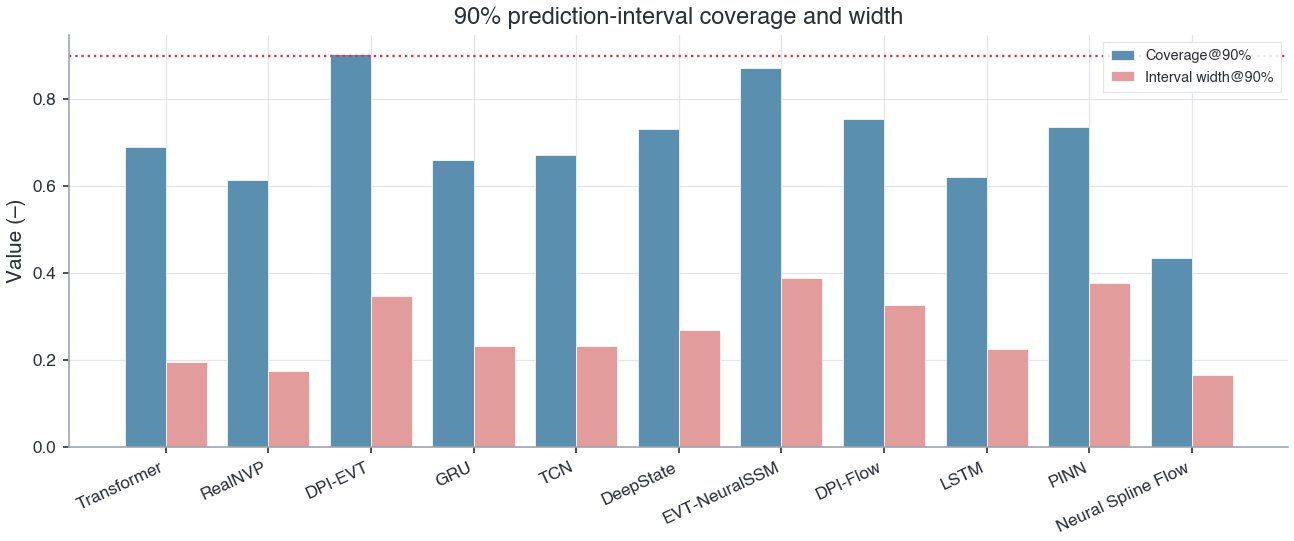

In [12]:
cov_df = leaderboard.dropna(subset=["Coverage_90"])[["model", "Coverage_90", "Interval_Width_90"]]
display(english_metric_table(cov_df).round(4))
fig = grouped_bar(cov_df["model"].tolist(),
                  {"Coverage@90%": cov_df["Coverage_90"].tolist(),
                   "Interval width@90%": cov_df["Interval_Width_90"].tolist()},
                  title="90% prediction-interval coverage and width", ylabel="Value (–)",
                  save=False, fig_id="3_1_coverage")
fig.add_hline(y=0.90, line_dash="dot", line_color="#dc3545")
from liquefaction_ai.viz import save_figure
save_figure(fig, "3_1_coverage", save=SAVE_FIGS)
fig.show()

## Итог

Структурированные модели дают CRR-границу, близкие к нулю (≤0.2%) нарушения монотонности и осмысленную неопределённость; конкретные лидеры по CRPS, Brier, N_liq и CRR берутся из сохранённых таблиц этого ноутбука.
Дальше — **3.2 абляции и OOD**.


In [13]:
# === A/B: conditional flow vs gaussian posterior (#3) ===
# Прямой тест центрального вопроса: даёт ли RealNVP-поток выигрыш по NLL/CRPS/Coverage против
# gaussian (use_flow=False) при прочих равных, с MC-mixture обучением. RUN_AB=True обучает 2 модели.
RUN_AB = True
if RUN_AB:
    from liquefaction_ai.evaluation import ab_flow_vs_gaussian
    from liquefaction_ai.evaluation.ab_test import train_ab_pair
    from liquefaction_ai.training.persistence import load_model_metadata
    _hp, _ = load_model_metadata(MODELS_DIR, "dpi_flow")
    _mf, _mg = train_ab_pair(benchmark, config, device, _hp["model_kwargs"])
    ab = ab_flow_vs_gaussian(_mf, _mg, test, config, device, n_samples=32, nboot=2000)
    _abdir = REPO_ROOT / "results" / "analysis_tables"; _abdir.mkdir(parents=True, exist_ok=True)
    ab.to_csv(_abdir / "ab_flow_vs_gaussian.csv", index=False)
    display(ab.round(4))
    print("Критерий #3: flow выигрывает, если P(flow_better) >= 0.95 по Traj_mixNLL и Traj_mixCRPS "
          "(меньше = лучше), а Coverage_90_objconf обоих в 0.88-0.92.")
else:
    print("A/B flow vs gaussian: поставь RUN_AB=True (обучит 2 модели-близнеца с MC-mixture).")


,metric,flow,gaussian,diff_gauss_minus_flow,ci95_low,ci95_high,P(flow_better)
0,Traj_mixNLL,-0.7579,-0.8986,-0.1407,-0.2900,0.0548,0.034
1,Traj_mixCRPS,0.0655,0.0632,-0.0023,-0.0063,0.0025,0.155


Критерий #3: flow выигрывает, если P(flow_better) >= 0.95 по Traj_mixNLL и Traj_mixCRPS (меньше = лучше), а Coverage_90_objconf обоих в 0.88-0.92.
